<a href="https://colab.research.google.com/github/Lasisi-Samson/NGX_30-CLUSTERING/blob/main/NGX_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('African Stock Markets.csv')




In [ ]:


def parse_financial_suffix(value):
    """
    Converts string formatted financial values (e.g. '1.5B', '200M', '45K')
    into actual numeric float values.
    """
    if pd.isna(value) or value == '-' or value == '':
        return np.nan

    if isinstance(value, (int, float)):
        return float(value)

    val_str = str(value).upper().strip().replace(',', '')

    # Check for multiplier suffixes
    multiplier = 1.0
    if val_str.endswith('T'):
        multiplier = 1e12  # Trillion
        val_str = val_str[:-1]
    elif val_str.endswith('B'):
        multiplier = 1e9   # Billion
        val_str = val_str[:-1]
    elif val_str.endswith('M'):
        multiplier = 1e6   # Million
        val_str = val_str[:-1]
    elif val_str.endswith('K'):
        multiplier = 1e3   # Thousand
        val_str = val_str[:-1]

    try:
        return float(val_str) * multiplier
    except ValueError:
        return np.nan

In [ ]:
# Create new numeric columns while keeping your original string columns untouched
df['market_cap_num'] = df['Market Cap'].apply(parse_financial_suffix)
df['volume_num'] = df['Average Volume (3m)'].apply(parse_financial_suffix)
df['revenue_num'] = df['Revenue'].apply(parse_financial_suffix)
df['PE_ratio'] = df['P/E Ratio'].apply(parse_financial_suffix)
df['Beta'] = df['Beta'].apply(parse_financial_suffix)

# Check the results
print(df[[ 'Beta', 'PE_ratio', 'market_cap_num', 'volume_num', 'revenue_num']])

     Beta  PE_ratio  market_cap_num   volume_num   revenue_num
0   1.030      3.45    1.610000e+12    1170000.0  2.240000e+09
1   0.106     14.66    6.360000e+12     178340.0  3.150000e+09
2   0.470     22.81    2.231000e+13      39870.0  6.880000e+09
3   0.190      8.76    3.249000e+11   10770000.0  8.374000e+10
4   0.390     94.01    2.480000e+12      57800.0  9.453000e+10
5   0.470     24.28    1.350000e+12     196490.0  1.946700e+11
6   0.540     17.66    2.420000e+12     188970.0  3.306500e+11
7   0.370      5.56    5.480200e+11   64760000.0  4.234900e+11
8  -0.290      5.45    4.268000e+11    3490000.0  5.066300e+11
9  -0.210     22.27    8.235800e+11     625660.0  5.152500e+11
10  0.180     42.48    1.990000e+12    2920000.0  6.201200e+11
11  0.247      2.66    7.551800e+11   32960000.0  6.268400e+11
12  0.190    -35.94    2.172900e+11      28930.0  7.877300e+11
13  0.005    556.09    9.559600e+11    7920000.0  7.908600e+11
14  0.440      6.47    2.530000e+12    2320000.0  7.929

In [ ]:
null = df.isnull().sum()
print(null)

Name                   0
Average Volume (3m)    0
Market Cap             0
Revenue                0
P/E Ratio              0
Beta                   0
market_cap_num         0
volume_num             0
revenue_num            0
PE_ratio               0
dtype: int64


In [ ]:
data = df[[ 'Beta', 'PE_ratio', 'market_cap_num', 'volume_num', 'revenue_num']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
X_scaled = scaled_data

# Evaluation

In [ ]:
def compute_penalized_posterior(X_scaled, Z, means, sigma2=1.0, prior_type="bic"):
    N, p = X_scaled.shape
    K = means.shape[0]

    # 1. Standard Gaussian Log-Likelihood
    assigned_means = means[Z]
    sq_err = np.sum((X_scaled - assigned_means) ** 2)
    log_likelihood = N * (-0.5 * p * np.log(2 * np.pi * sigma2)) - (1.0 / (2.0 * sigma2)) * sq_err

    # 2. Prior Penalty on K
    if prior_type == "bic":
        # Penalize K * p parameters
        log_prior = -0.5 * (K * p) * np.log(N)
    elif prior_type == "gaussian_means":
        # Prior: mu_k ~ N(0, 10^2)
        sigma02 = 100.0
        log_prior = np.sum(-0.5 * p * np.log(2 * np.pi * sigma02) - np.sum(means**2, axis=1) / (2 * sigma02))
    else:
        log_prior = 0.0  # Raw unpenalized (will overfit)

    return log_likelihood, log_prior, log_likelihood + log_prior

In [ ]:
def evaluate_kmeans_models1(X_scaled, k_range=range(2, 10), sigma2=None, random_state=42):
    """
    Runs K-Means across a range of K values and evaluates each model.
    """
    results = []

    for k in k_range:
        # Fit K-Means
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        Z = kmeans.fit_predict(X_scaled)
        means = kmeans.cluster_centers_

        # Evaluate model score
        log_likelihood, log_prior, log_posterior = compute_penalized_posterior(X_scaled, Z, means, sigma2=sigma2)
        results.append({
            "K": k,
            "log_likelihood": log_likelihood,
            "log_prior": log_prior,
            "log_posterior": log_posterior
        })

    return results

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# --- Step 2: Evaluate K from 2 to 8 ---
k_range = range(2, 9)
eval_results = evaluate_kmeans_models1(X_scaled, k_range=k_range, sigma2=1.0)

# --- Step 3: Print Results ---
print(f"{'K':<4} | {'Log Likelihood':<15} | {'Log Prior':<12} | {'Log Posterior':<15}")
print("-" * 55)
for r in eval_results:
    print(f"{r['K']:<4} | {r['log_likelihood']:<15.2f} | {r['log_prior']:<12.2f} | {r['log_posterior']:<15.2f}")

# Optimal K has the highest log-posterior score
best_model = max(eval_results, key=lambda r: r['log_posterior'])
print(f"\nBest model: K = {best_model['K']} with Log-Posterior = {best_model['log_posterior']:.2f}")

K    | Log Likelihood  | Log Prior    | Log Posterior  
-------------------------------------------------------
2    | -180.74         | -16.66       | -197.40        
3    | -167.41         | -24.99       | -192.40        
4    | -155.48         | -33.32       | -188.81        
5    | -150.11         | -41.65       | -191.76        
6    | -144.91         | -49.98       | -194.89        
7    | -141.87         | -58.31       | -200.18        
8    | -139.45         | -66.64       | -206.09        

Best model: K = 4 with Log-Posterior = -188.81


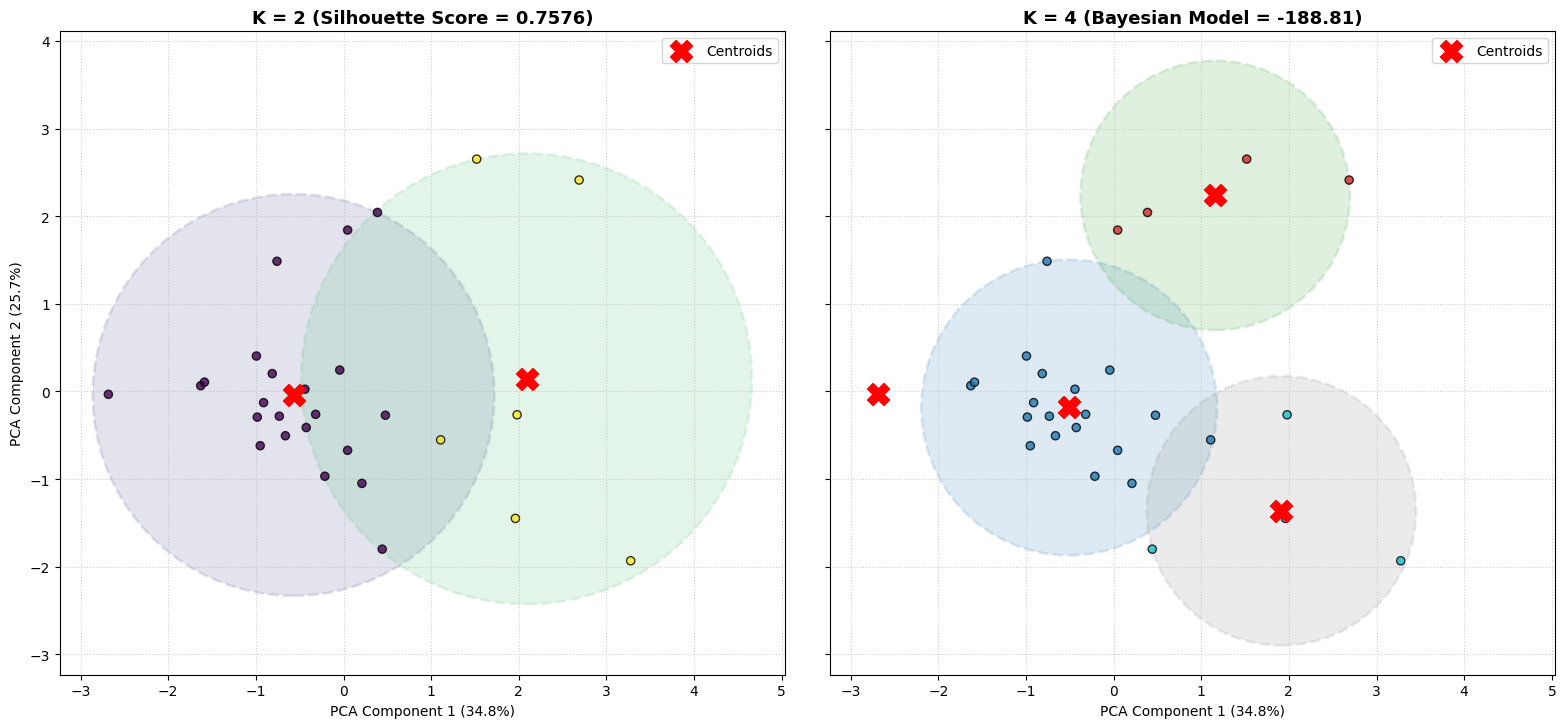

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Prepare Data & Fit PCA
# ==========================================


# Reduce to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

# ==========================================
# 2. Fit K-Means for K=2 and K=4
# ==========================================
kmeans_k2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_scaled)
labels_k2 = kmeans_k2.labels_
centers_k2_pca = pca.transform(kmeans_k2.cluster_centers_)

kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
labels_k4 = kmeans_k4.labels_
centers_k4_pca = pca.transform(kmeans_k4.cluster_centers_)


# Function to add boundary circles around clusters
def add_cluster_circles(ax, X_2d, labels, centroids, cmap_name):
    cmap = plt.get_cmap(cmap_name)
    unique_labels = np.unique(labels)

    for k in unique_labels:
        # Extract points belonging to cluster k in 2D space
        cluster_points = X_2d[labels == k]
        center = centroids[k]

        # Radius = maximum distance from center to any point in the cluster
        distances = np.linalg.norm(cluster_points - center, axis=1)
        radius = np.max(distances)

        # Color matching the scatter plot
        color = cmap(k / len(unique_labels)) if len(unique_labels) > 2 else cmap(k / 2 + 0.2)

        # Draw transparent filled circle with a solid border
        circle = Circle(
            center, radius,
            edgecolor=color, facecolor=color, alpha=0.15, linewidth=2, linestyle='--'
        )
        ax.add_patch(circle)


# ==========================================
# 3. Side-by-Side Visualization
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# --- Plot K = 2 ---
axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels_k2, cmap='viridis', alpha=0.8, edgecolors='k', s=35, zorder=3
)
axes[0].scatter(
    centers_k2_pca[:, 0], centers_k2_pca[:, 1],
    c='red', marker='X', s=250, zorder=4, label='Centroids'
)
add_cluster_circles(axes[0], X_pca, labels_k2, centers_k2_pca, 'viridis')

axes[0].set_title("K = 2 (Silhouette Score = 0.7576)", fontsize=13, fontweight='bold')
axes[0].set_xlabel(f"PCA Component 1 ({var_explained[0]:.1f}%)")
axes[0].set_ylabel(f"PCA Component 2 ({var_explained[1]:.1f}%)")
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].set_aspect('equal', adjustable='box') # Changed from 'datalim' to 'box'

# --- Plot K = 4 ---
axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels_k4, cmap='tab10', alpha=0.8, edgecolors='k', s=35, zorder=3
)
axes[1].scatter(
    centers_k4_pca[:, 0], centers_k4_pca[:, 1],
    c='red', marker='X', s=250, zorder=4, label='Centroids'
)
add_cluster_circles(axes[1], X_pca, labels_k4, centers_k4_pca, 'tab10')

axes[1].set_title("K = 4 (Bayesian Model = -188.81)", fontsize=13, fontweight='bold')
axes[1].set_xlabel(f"PCA Component 1 ({var_explained[0]:.1f}%)")
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].set_aspect('equal', adjustable='box') # Changed from 'datalim' to 'box'

plt.tight_layout()
plt.show()